In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
  
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 
  
# metadata 
print(abalone.metadata) 
  
# variable information 
print(abalone.variables) 

# combinare într-un singur DataFrame
df = pd.concat([X, y], axis=1)

# y ca Series
y = y.squeeze()

# vârsta reală a unei moluște este de 1,5 ani * 
y_age = y + 1.5

# afișare primele linii
print(df.head())

{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

# 

Setul de date

Vom folosi setul de date ABALONE in care pe baza caracteristicilor moluștelor dorim să putem determina vârsta uneia fără a-i număra cercurile formate pe cochilie, măsurare care este o procedură meticuloasă.

Setul de date poate fi gasit si pe link-ul urmator:

https://http://archive.ics.uci.edu/dataset/1/abalone

In [2]:
X.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [3]:
y.head()

0    15
1     7
2     9
3    10
4     7
Name: Rings, dtype: int64

In [4]:
y.value_counts()

Rings
9     689
10    634
8     568
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
27      2
24      2
1       1
26      1
29      1
2       1
25      1
Name: count, dtype: int64

# Verificam daca avem valori nule

In [5]:
X.isna().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
dtype: int64

In [6]:
list(y.value_counts().keys())

[9,
 10,
 8,
 11,
 7,
 12,
 6,
 13,
 14,
 5,
 15,
 16,
 17,
 4,
 18,
 19,
 20,
 3,
 21,
 23,
 22,
 27,
 24,
 1,
 26,
 29,
 2,
 25]

In [11]:
# variabila categorială Sex este transformată în una numerică
df_numeric = pd.get_dummies(df, columns=["Sex"])

# Verificam distributiile variabilelor continue

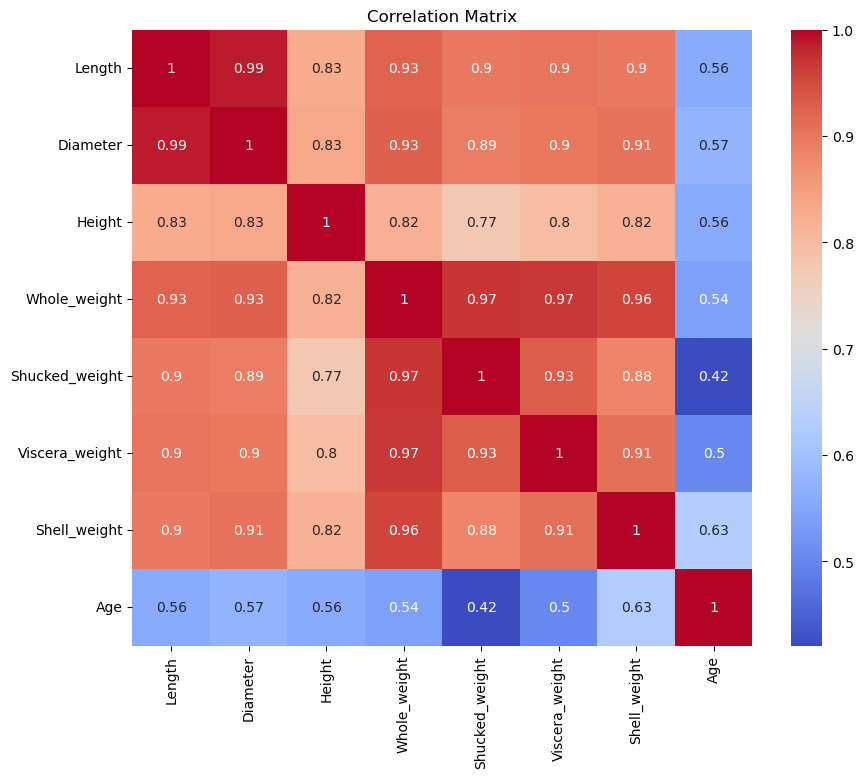

In [12]:
df = pd.concat([X, y_age.rename("Age")], axis=1)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

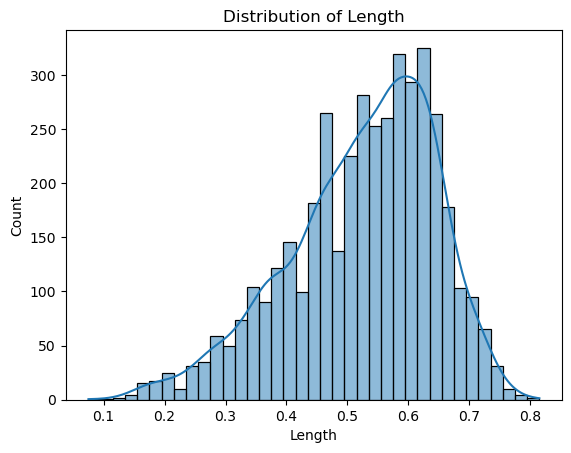

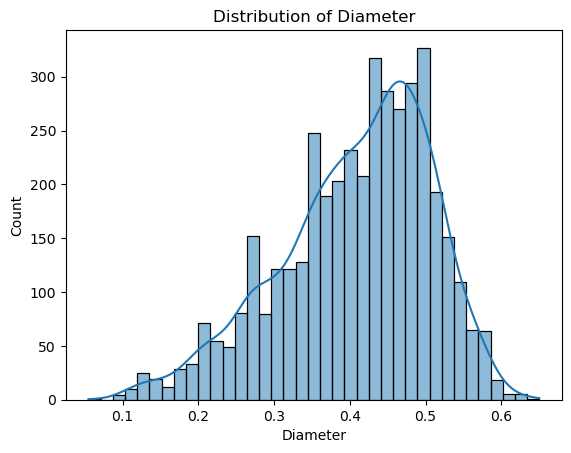

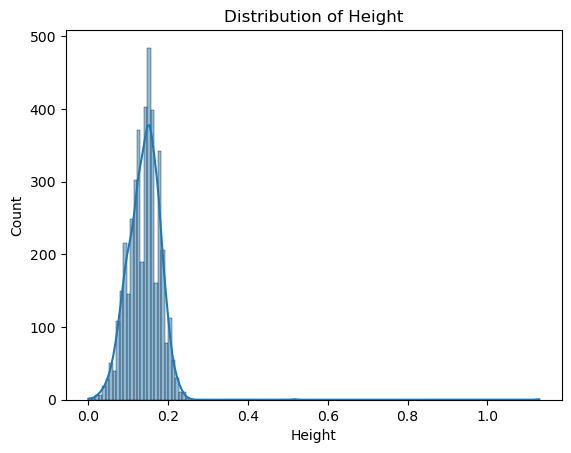

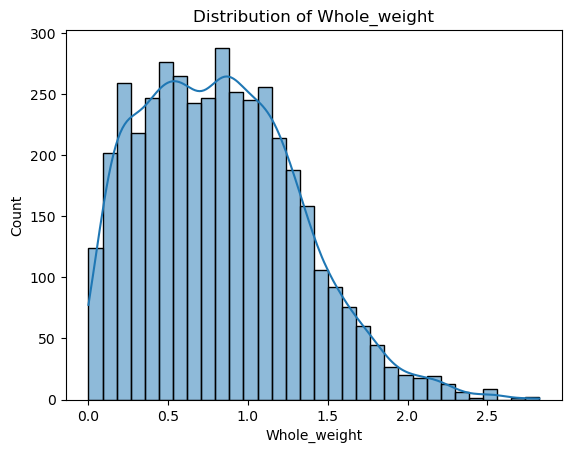

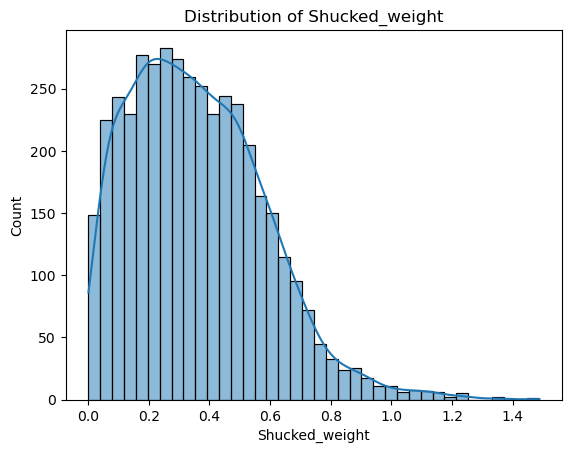

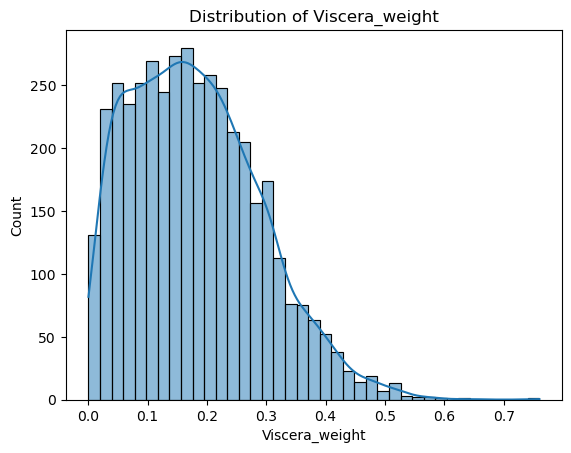

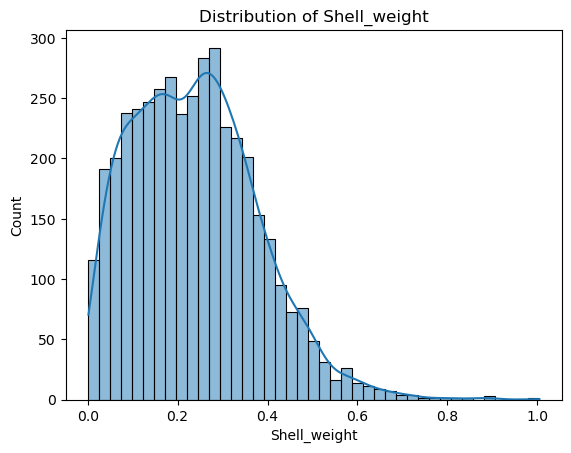

In [13]:
for column in X.columns:
    if X[column].dtype != "object":
        plt.figure()
        sns.histplot(X[column], kde=True)
        plt.title(f"Distribution of {column}")
        plt.show()

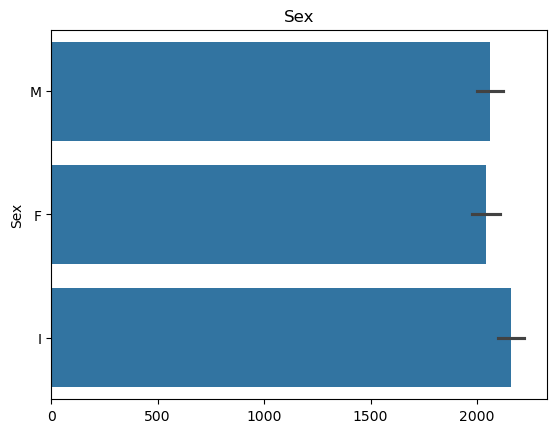

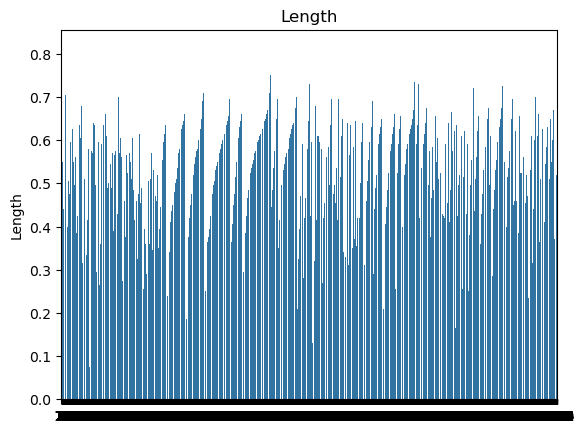

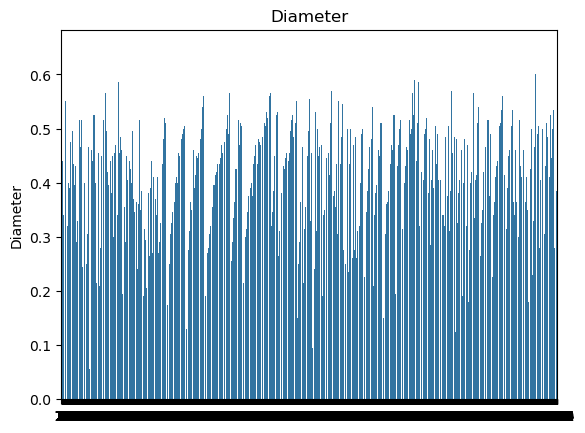

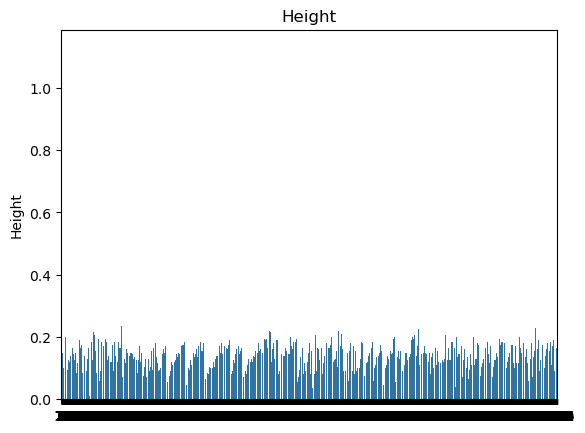

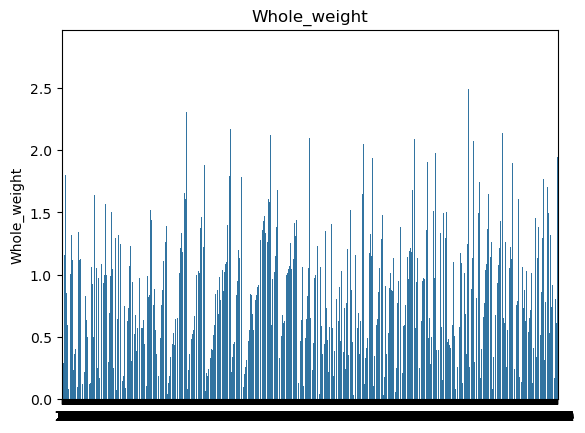

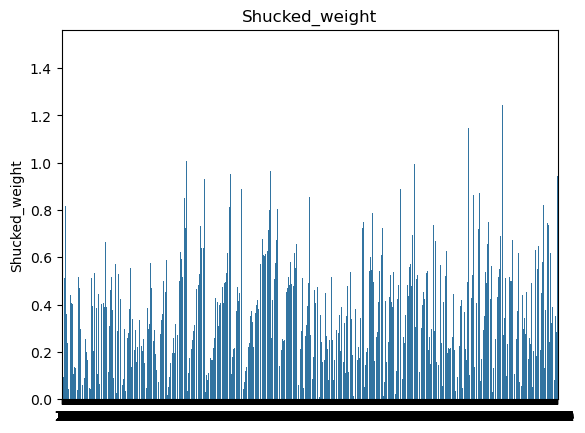

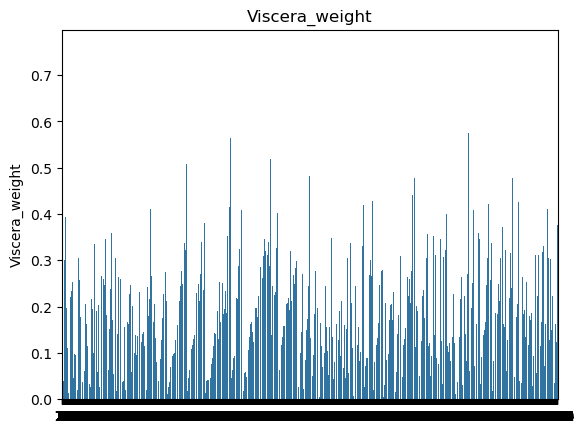

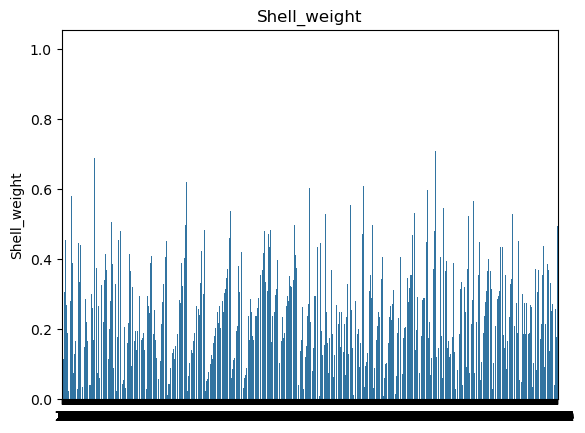

In [9]:
columns = list(X.columns)
for column in columns:
    plt.figure()
    sns.barplot(X[column])
    plt.title(column)

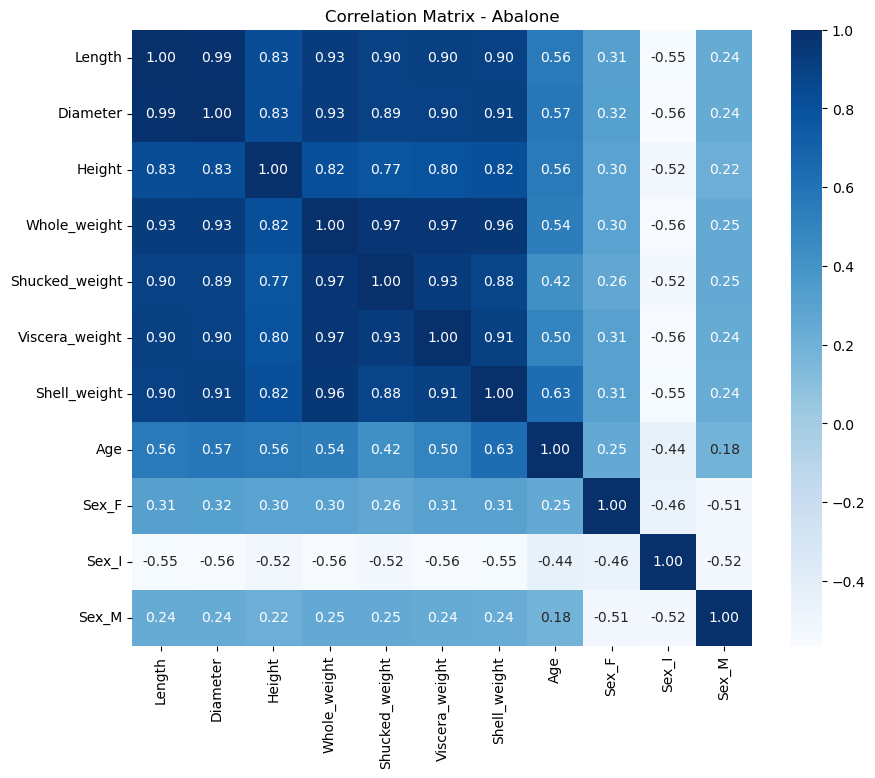

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_numeric.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix - Abalone")
plt.show()